# Modelo de Machine Learning para Predicción de Supervivencia en el Titanic

**Materia:** Aplicaciones de Analítica de Negocios 2  
**Objetivo:** Desarrollar un modelo de clasificación en Python que prediga si un pasajero sobrevivió al hundimiento del Titanic.

---
## Índice
1. Importación de librerías
2. Exploración de datos
3. Preprocesamiento de datos
4. Selección y entrenamiento de modelos
5. Evaluación de modelos
6. Predicción y exportación


## 1. Importación de Librerías
Se importan las principales librerías para análisis, visualización y modelado de datos.

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from sklearn.utils import resample
from sklearn import tree
import joblib

sns.set_theme(color_codes=True)
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

## 2. Exploración de Datos
### 2.1 Carga del Dataset
Se carga el dataset `train.csv` en un DataFrame de pandas.

In [35]:
df = pd.read_csv('train.csv', delimiter=',')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2.2 Información General del Dataset
Se valida el tipo de información disponible, el número de registros y si existen valores nulos.

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [37]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print()
print('Porcentaje de nulos por columna:')
print((df.isnull().sum() / len(df) * 100).round(2))

Valores nulos por columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Porcentaje de nulos por columna:
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


### 2.3 Estadísticas Descriptivas
Se extraen métricas útiles para entender la distribución de los datos numéricos.

In [38]:
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [39]:
print(f"Total de pasajeros: {len(df)}")
print(f"Supervivientes: {df['Survived'].sum()} ({df['Survived'].mean()*100:.1f}%)")
print(f"No supervivientes: {(df['Survived']==0).sum()} ({(df['Survived']==0).mean()*100:.1f}%)")
print(f"Edad promedio: {df['Age'].mean():.1f} años")
print(f"Edad mínima: {df['Age'].min():.1f} años")
print(f"Edad máxima: {df['Age'].max():.1f} años")

Total de pasajeros: 891
Supervivientes: 342 (38.4%)
No supervivientes: 549 (61.6%)
Edad promedio: 29.7 años
Edad mínima: 0.4 años
Edad máxima: 80.0 años


### 2.4 Visualización Exploratoria
Se generan gráficas para entender la relación entre las variables y la variable objetivo `Survived`.

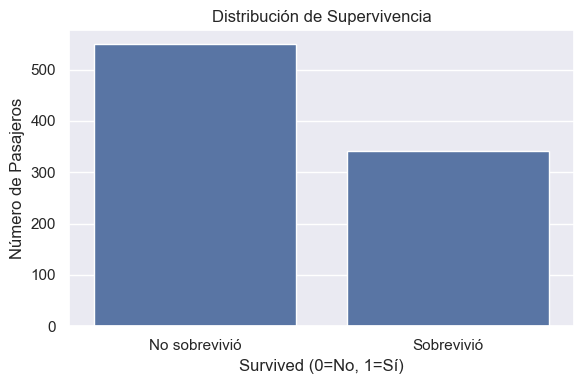

In [40]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df)
plt.title('Distribución de Supervivencia')
plt.xlabel('Survived (0=No, 1=Sí)')
plt.ylabel('Número de Pasajeros')
plt.xticks([0, 1], ['No sobrevivió', 'Sobrevivió'])
plt.tight_layout()
plt.show()

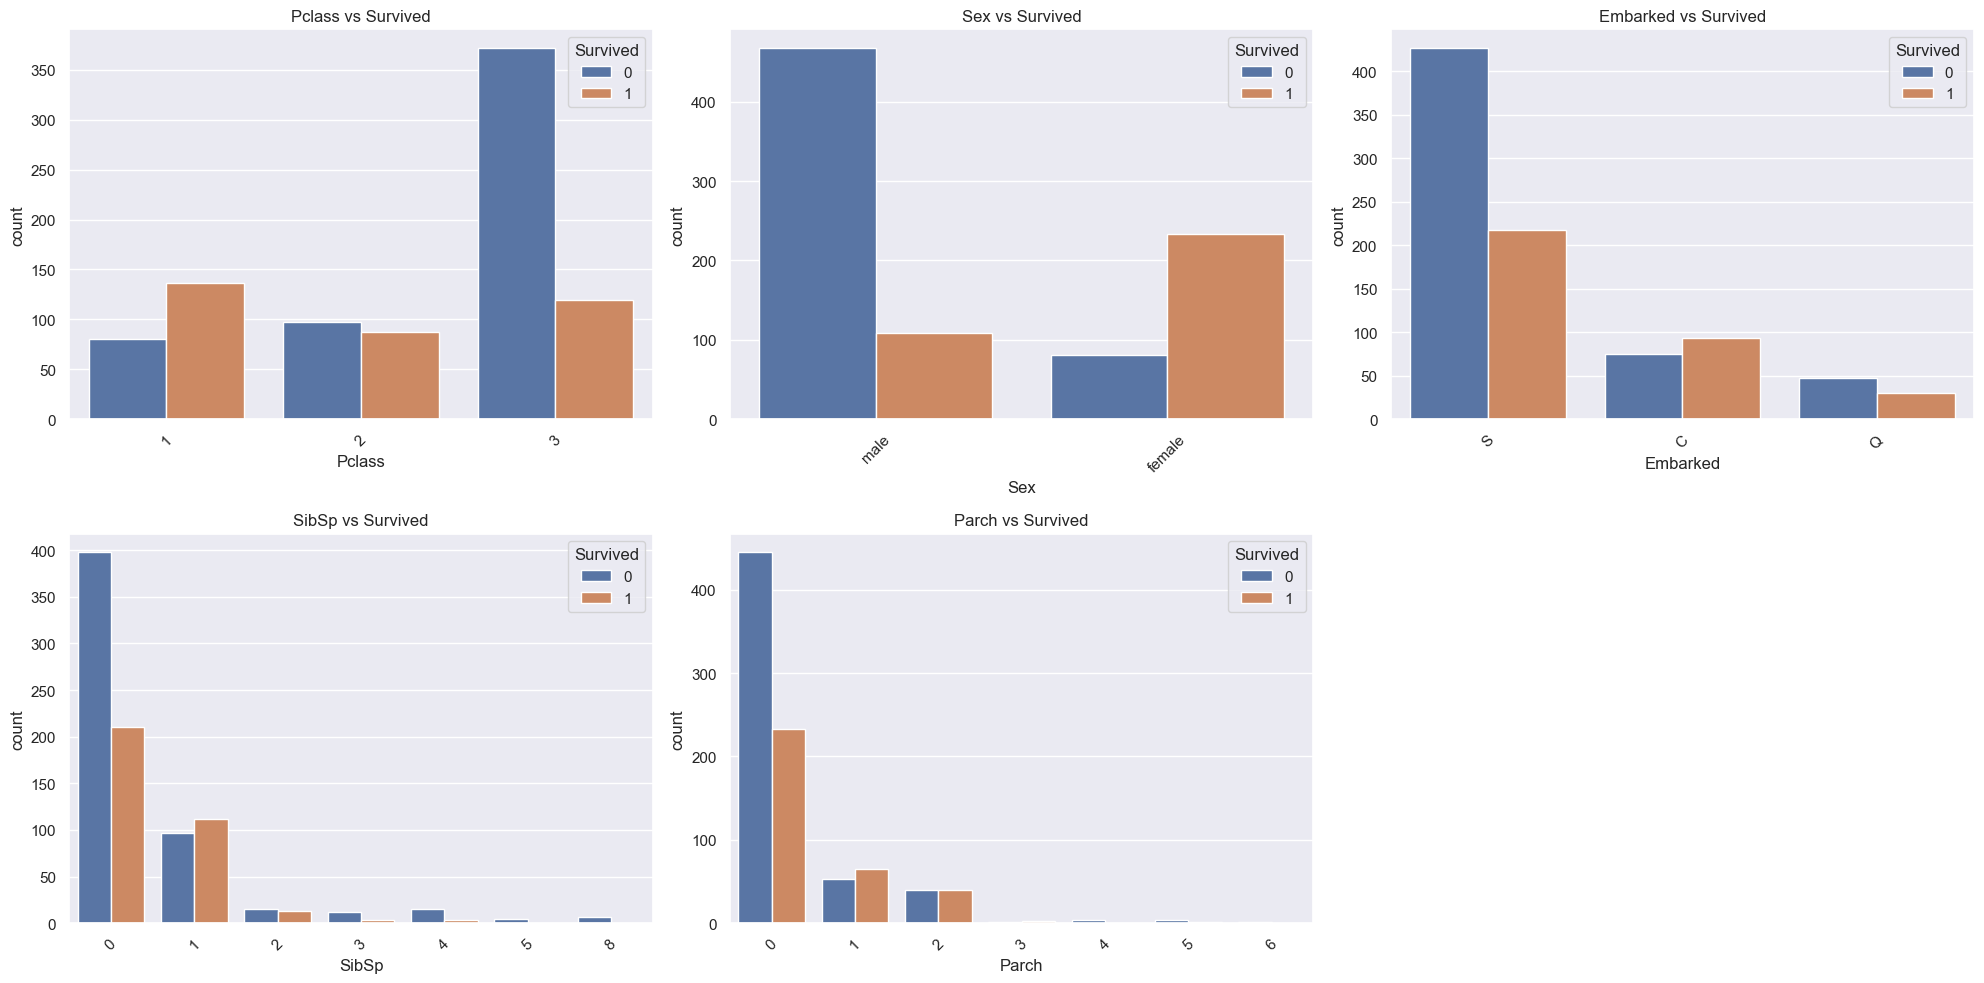

In [41]:
cat_vars = ['Pclass', 'Sex', 'Embarked', 'SibSp', 'Parch']

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axs = axs.flatten()

for i, var in enumerate(cat_vars):
    sns.countplot(x=var, hue='Survived', data=df, ax=axs[i])
    axs[i].set_title(f'{var} vs Survived')
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=45)

axs[5].axis('off')
fig.tight_layout()
plt.show()

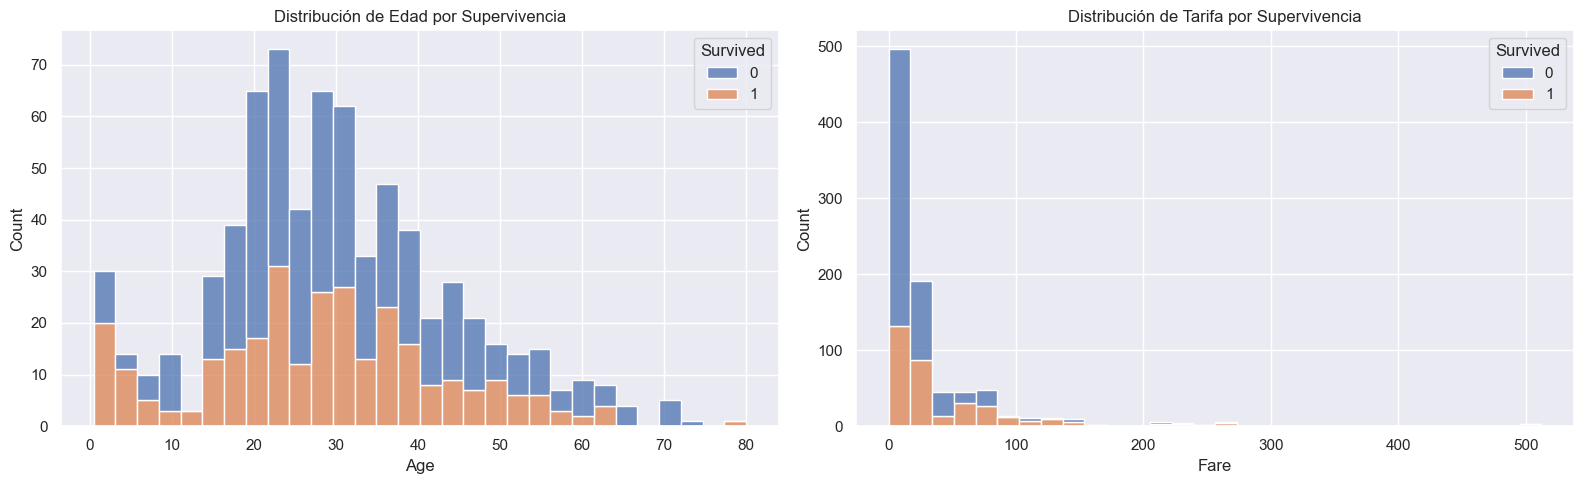

In [42]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

sns.histplot(x='Age', hue='Survived', data=df, ax=axs[0], multiple='stack', bins=30)
axs[0].set_title('Distribución de Edad por Supervivencia')

sns.histplot(x='Fare', hue='Survived', data=df, ax=axs[1], multiple='stack', bins=30)
axs[1].set_title('Distribución de Tarifa por Supervivencia')

fig.tight_layout()
plt.show()

**Observaciones clave de la exploración:**
- Solo el ~38% de los pasajeros sobrevivió (dataset desbalanceado).
- Las mujeres tienen una tasa de supervivencia mucho mayor que los hombres (prioridad de evacuación).
- Los pasajeros de 1ª clase sobrevivieron en mayor proporción que los de 3ª clase.
- La edad promedio es ~30 años; los niños tuvieron mayor probabilidad de sobrevivir.
- Las tarifas más altas se asocian con mayor supervivencia (correlación con clase del boleto).

## 3. Preprocesamiento de Datos

### 3.1 Ingeniería de Características
Se crean nuevas variables que pueden mejorar el poder predictivo del modelo.

In [44]:
# FamilySize: tamaño del grupo familiar a bordo
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# IsAlone: indicador de si el pasajero viajaba solo
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Title: título social extraído del nombre (indicador relevante de clase y género)
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Agrupar títulos poco frecuentes en categoría 'Rare'
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

print('Distribución de títulos:')
print(df['Title'].value_counts())
df[['Name', 'Title', 'FamilySize', 'IsAlone']].head()

Distribución de títulos:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


,Name,Title,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",Mr,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0
2,"Heikkinen, Miss. Laina",Miss,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0
4,"Allen, Mr. William Henry",Mr,1,1


### 3.2 Manejo de Valores Faltantes
Se tratan los valores nulos de cada columna de manera adecuada:
- **Age**: se imputa con la mediana agrupada por `Title` (preserva el perfil social del pasajero).
- **Embarked**: se imputa con la moda (solo 2 valores faltantes).
- **Cabin**: se elimina porque el 77% de los valores son nulos.

In [45]:
# Imputar Age con la mediana agrupada por Title
age_median_by_title = df.groupby('Title')['Age'].median()
print('Mediana de edad por título:')
print(age_median_by_title)

df['Age'] = df.apply(
    lambda row: age_median_by_title[row['Title']] if pd.isnull(row['Age']) else row['Age'],
    axis=1
)

# Imputar Embarked con la moda
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print(f'\nValores nulos restantes:')
print(df.isnull().sum())

Mediana de edad por título:
Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64

Valores nulos restantes:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
FamilySize       0
IsAlone          0
Title            0
dtype: int64


### 3.3 Eliminación de Columnas Irrelevantes
Se eliminan columnas que no aportan valor predictivo o que ya fueron transformadas en nuevas features.

In [46]:
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df = df.drop(columns=cols_to_drop)
print(f'Columnas restantes: {list(df.columns)}')
df.head()

Columnas restantes: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
0,0,3,male,22.0,1,0,7.2500,S,2,0,Mr
1,1,1,female,38.0,1,0,71.2833,C,2,0,Mrs
2,1,3,female,26.0,0,0,7.9250,S,1,1,Miss
3,1,1,female,35.0,1,0,53.1000,S,2,0,Mrs
4,0,3,male,35.0,0,0,8.0500,S,1,1,Mr


### 3.4 Conversión de Variables Categóricas a Numéricas
Se transforman las variables categóricas a valores numéricos para que puedan ser procesadas por los modelos de ML.
Se utilizan dos métodos: diccionario de mapeo (cuando los valores tienen un significado claro) y LabelEncoder.

In [47]:
# Mapeo directo para Sex
sex_mapping = {'male': 0, 'female': 1}
df['Sex'] = df['Sex'].map(sex_mapping)
print(f"Sex -> valores únicos: {df['Sex'].unique()}")

# Mapeo para Embarked (puerto de embarque)
embarked_mapping = {'S': 0, 'C': 1, 'Q': 2}
df['Embarked'] = df['Embarked'].map(embarked_mapping)
print(f"Embarked -> valores únicos: {df['Embarked'].unique()}")

# LabelEncoder para Title
label_encoder_title = preprocessing.LabelEncoder()
print(f"Title antes: {df['Title'].unique()}")
df['Title'] = label_encoder_title.fit_transform(df['Title'])
print(f"Title después: {df['Title'].unique()}")
print(f"Clases: {label_encoder_title.classes_}")

df.head()

Sex -> valores únicos: [0 1]
Embarked -> valores únicos: [0 1 2]
Title antes: <StringArray>
['Mr', 'Mrs', 'Miss', 'Master', 'Rare']
Length: 5, dtype: str
Title después: [2 3 1 0 4]
Clases: ['Master' 'Miss' 'Mr' 'Mrs' 'Rare']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
0,0,3,0,22.0,1,0,7.2500,0,2,0,2
1,1,1,1,38.0,1,0,71.2833,1,2,0,3
2,1,3,1,26.0,0,0,7.9250,0,1,1,1
3,1,1,1,35.0,1,0,53.1000,0,2,0,3
4,0,3,0,35.0,0,0,8.0500,0,1,1,2


### 3.5 Eliminación de Registros Duplicados
Se evalúa la cantidad de filas duplicadas y se eliminan para evitar sesgo en el entrenamiento.

In [48]:
print(f'Número de registros antes: {len(df)}')
num_duplicados = df.duplicated(keep=False).sum()
print(f'Número de registros duplicados: {num_duplicados}')
df = df.drop_duplicates()
print(f'Número de registros después: {len(df)}')

Número de registros antes: 891
Número de registros duplicados: 167
Número de registros después: 778


### 3.6 Eliminación de Outliers
Se identifican y eliminan valores atípicos en variables numéricas usando el método IQR (Rango Intercuartílico).

In [49]:
def remove_outliers_iqr(df, columns):
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

print(f'Registros antes de eliminar outliers: {len(df)}')
columns_to_check = ['Age', 'Fare', 'FamilySize']
df_clean = remove_outliers_iqr(df, columns_to_check)
print(f'Registros después de eliminar outliers: {len(df_clean)}')

Registros antes de eliminar outliers: 778
Registros después de eliminar outliers: 583


### 3.7 Matriz de Correlación
Se calcula y visualiza la correlación entre variables para identificar relaciones lineales con la variable objetivo `Survived`.

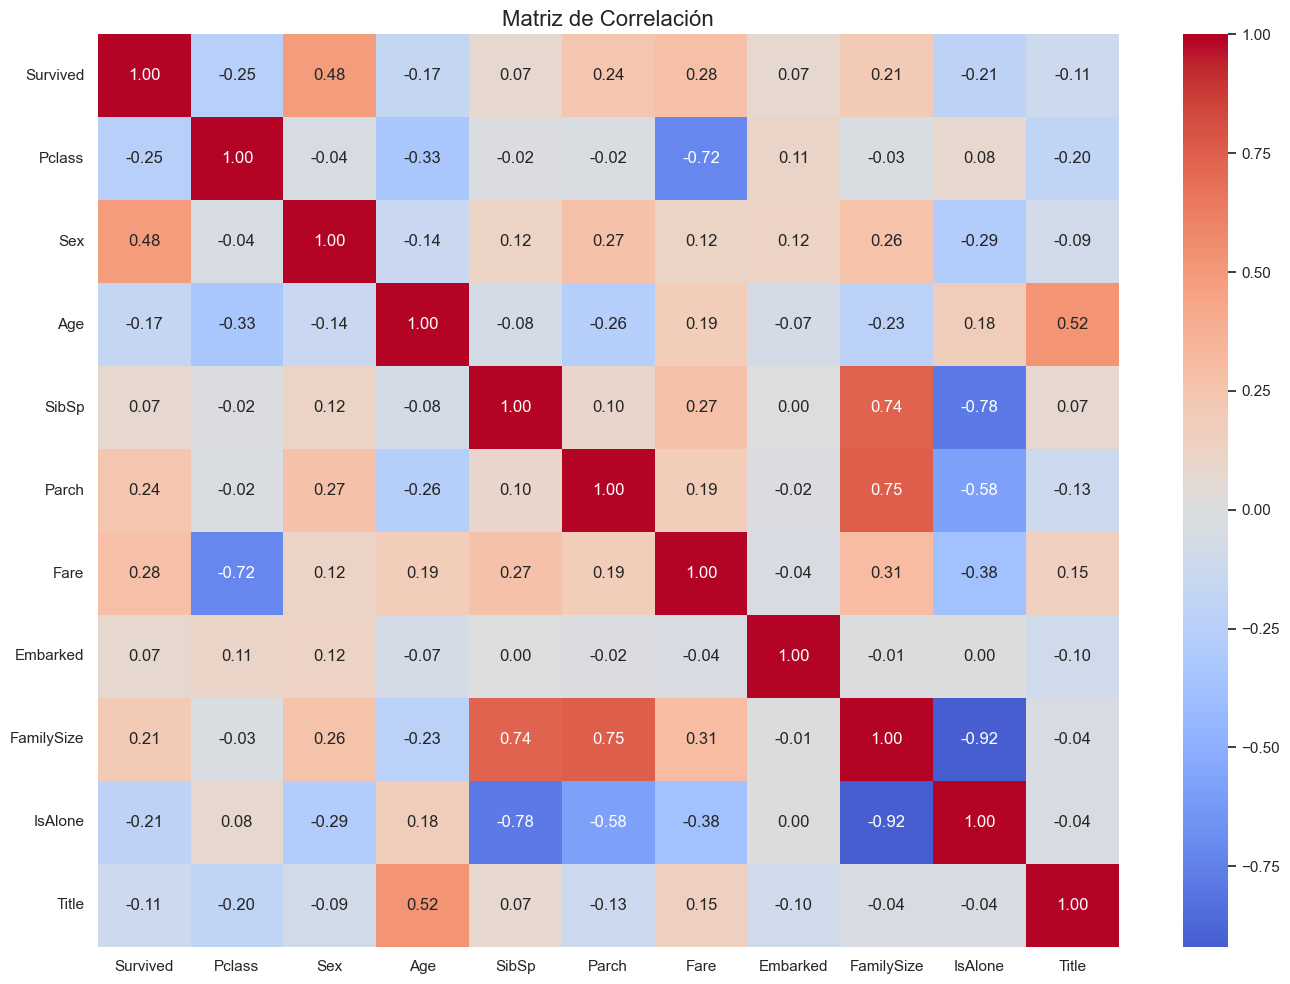


Correlación con Survived (ordenado):
Survived      1.000000
Sex           0.483704
Fare          0.278956
Parch         0.238829
FamilySize    0.210768
SibSp         0.072322
Embarked      0.072124
Title        -0.113914
Age          -0.165797
IsAlone      -0.207675
Pclass       -0.253829
Name: Survived, dtype: float64


In [50]:
corr_matrix = df_clean.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlación', fontsize=16)
plt.tight_layout()
plt.show()

print('\nCorrelación con Survived (ordenado):')
print(corr_matrix['Survived'].sort_values(ascending=False))

## 4. Selección y Entrenamiento del Modelo

### 4.1 Separación de Variables Predictoras y Variable Objetivo
Se separa el dataset en `X` (características) y `y` (variable a predecir: `Survived`).

In [51]:
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

print(f'Dimensiones de X: {X.shape}')
print(f'Dimensiones de y: {y.shape}')
print(f'\nVariables predictoras: {list(X.columns)}')

Dimensiones de X: (583, 10)
Dimensiones de y: (583,)

Variables predictoras: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']


### 4.2 División en Conjuntos de Entrenamiento y Prueba
Se divide el conjunto de datos: 80% entrenamiento y 20% prueba, con `random_state=0` para reproducibilidad.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print(f'Registros de entrenamiento: {len(X_train)}')
print(f'Registros de prueba: {len(X_test)}')

Registros de entrenamiento: 466
Registros de prueba: 117


### 4.3 Balanceo de Clases
El balanceo de clases se realiza para evitar que el modelo se sesgue hacia la clase mayoritaria (no sobrevivió).
Se aplica oversampling sobre la clase minoritaria (sobrevivió) usando la función `resample`.

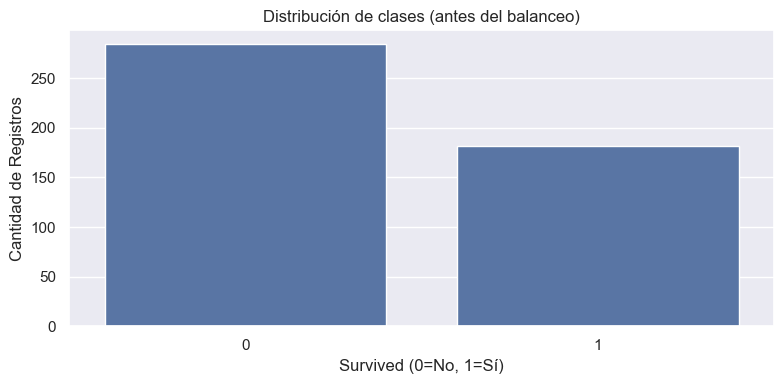

Survived
0    284
1    182
Name: count, dtype: int64


In [53]:
train_data = pd.concat([X_train, y_train], axis=1)

plt.figure(figsize=(8, 4))
sns.countplot(x='Survived', data=train_data)
plt.title('Distribución de clases (antes del balanceo)')
plt.xlabel('Survived (0=No, 1=Sí)')
plt.ylabel('Cantidad de Registros')
plt.tight_layout()
plt.show()

print(train_data['Survived'].value_counts())

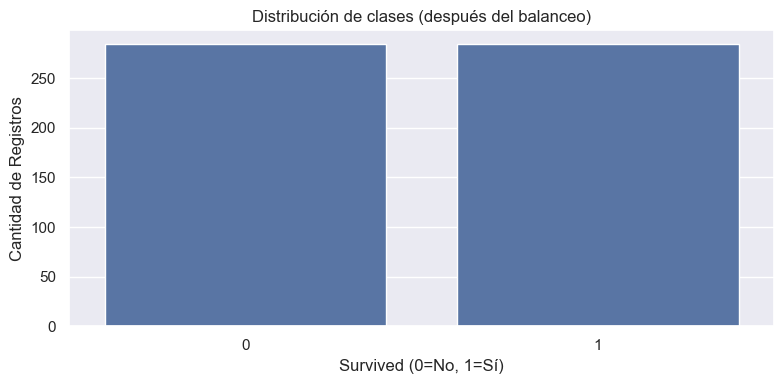

Survived
0    284
1    284
Name: count, dtype: int64


In [54]:
majority_class = train_data[train_data['Survived'] == 0]
minority_class = train_data[train_data['Survived'] == 1]

minority_upsampled = resample(
    minority_class,
    replace=True,
    n_samples=len(majority_class),
    random_state=42
)

balanced_train_data = pd.concat([majority_class, minority_upsampled])

plt.figure(figsize=(8, 4))
sns.countplot(x='Survived', data=balanced_train_data)
plt.title('Distribución de clases (después del balanceo)')
plt.xlabel('Survived (0=No, 1=Sí)')
plt.ylabel('Cantidad de Registros')
plt.tight_layout()
plt.show()

print(balanced_train_data['Survived'].value_counts())

X_train = balanced_train_data.drop('Survived', axis=1)
y_train = balanced_train_data['Survived']

### 4.4 Modelo 1: Árbol de Decisión (Criterio GINI)
Se entrena un árbol de decisión con criterio de impureza Gini y profundidad máxima de 5.  
**Justificación:** Los árboles de decisión son fácilmente interpretables; permiten visualizar las reglas de clasificación y entender qué variables determinan la supervivencia.

In [55]:
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=0)
clf_gini.fit(X_train, y_train)
print('Modelo Árbol de Decisión (GINI) entrenado exitosamente.')

Modelo Árbol de Decisión (GINI) entrenado exitosamente.


In [56]:
y_pred_train_dt = clf_gini.predict(X_train)
y_pred_dt = clf_gini.predict(X_test)

print('=== Árbol de Decisión (GINI) ===')
print(f'Accuracy en entrenamiento : {round(accuracy_score(y_train, y_pred_train_dt)*100, 2)}%')
print(f'Accuracy en prueba        : {round(accuracy_score(y_test, y_pred_dt)*100, 2)}%')

=== Árbol de Decisión (GINI) ===
Accuracy en entrenamiento : 80.28%
Accuracy en prueba        : 75.21%


### 4.5 Modelo 2: Random Forest
Se entrena un modelo de Random Forest con 100 árboles, criterio GINI y profundidad máxima de 5.  
**Justificación:** Random Forest reduce el sobreajuste del árbol individual al promediar las predicciones de múltiples árboles, obteniendo mejor generalización.

In [57]:
modelRF = RandomForestClassifier(criterion='gini', max_depth=5, n_estimators=100, random_state=0)
modelRF.fit(X_train, y_train)
print('Modelo Random Forest entrenado exitosamente.')

Modelo Random Forest entrenado exitosamente.


In [58]:
y_pred_train_rf = modelRF.predict(X_train)
y_pred_rf = modelRF.predict(X_test)

print('=== Random Forest ===')
print(f'Accuracy en entrenamiento : {round(accuracy_score(y_train, y_pred_train_rf)*100, 2)}%')
print(f'Accuracy en prueba        : {round(accuracy_score(y_test, y_pred_rf)*100, 2)}%')

=== Random Forest ===
Accuracy en entrenamiento : 80.28%
Accuracy en prueba        : 76.07%


### 4.6 Modelo 3: Regresión Logística
Se entrena una Regresión Logística como tercer modelo de clasificación.  
**Justificación:** La regresión logística sirve como línea base de comparación. Es un modelo lineal robusto e interpretable que funciona bien cuando las variables tienen relaciones lineales con la variable objetivo.

In [59]:
modelLR = LogisticRegression(max_iter=1000, random_state=0)
modelLR.fit(X_train, y_train)
print('Modelo Regresión Logística entrenado exitosamente.')

Modelo Regresión Logística entrenado exitosamente.


In [60]:
y_pred_train_lr = modelLR.predict(X_train)
y_pred_lr = modelLR.predict(X_test)

print('=== Regresión Logística ===')
print(f'Accuracy en entrenamiento : {round(accuracy_score(y_train, y_pred_train_lr)*100, 2)}%')
print(f'Accuracy en prueba        : {round(accuracy_score(y_test, y_pred_lr)*100, 2)}%')

=== Regresión Logística ===
Accuracy en entrenamiento : 75.53%
Accuracy en prueba        : 73.5%


## 5. Evaluación de Modelos

### 5.1 Comparativa General de Modelos
Se construye una tabla comparativa con las métricas principales de cada modelo evaluado.

In [61]:
results = pd.DataFrame({
    'Modelo': ['Árbol de Decisión (GINI)', 'Random Forest', 'Regresión Logística'],
    'Accuracy Train (%)': [
        round(accuracy_score(y_train, y_pred_train_dt)*100, 2),
        round(accuracy_score(y_train, y_pred_train_rf)*100, 2),
        round(accuracy_score(y_train, y_pred_train_lr)*100, 2)
    ],
    'Accuracy Test (%)': [
        round(accuracy_score(y_test, y_pred_dt)*100, 2),
        round(accuracy_score(y_test, y_pred_rf)*100, 2),
        round(accuracy_score(y_test, y_pred_lr)*100, 2)
    ],
    'F1 Score': [
        round(f1_score(y_test, y_pred_dt, average='weighted'), 4),
        round(f1_score(y_test, y_pred_rf, average='weighted'), 4),
        round(f1_score(y_test, y_pred_lr, average='weighted'), 4)
    ],
    'Precision': [
        round(precision_score(y_test, y_pred_dt, average='weighted'), 4),
        round(precision_score(y_test, y_pred_rf, average='weighted'), 4),
        round(precision_score(y_test, y_pred_lr, average='weighted'), 4)
    ],
    'Recall': [
        round(recall_score(y_test, y_pred_dt, average='weighted'), 4),
        round(recall_score(y_test, y_pred_rf, average='weighted'), 4),
        round(recall_score(y_test, y_pred_lr, average='weighted'), 4)
    ]
})

results

,Modelo,Accuracy Train (%),Accuracy Test (%),F1 Score,Precision,Recall
0,Árbol de Decisión (GINI),80.28,75.21,0.7471,0.7478,0.7521
1,Random Forest,80.28,76.07,0.7607,0.7607,0.7607
2,Regresión Logística,75.53,73.50,0.7366,0.7392,0.7350


### 5.2 Matrices de Confusión
Se visualizan las matrices de confusión de los tres modelos para analizar verdaderos/falsos positivos y negativos.

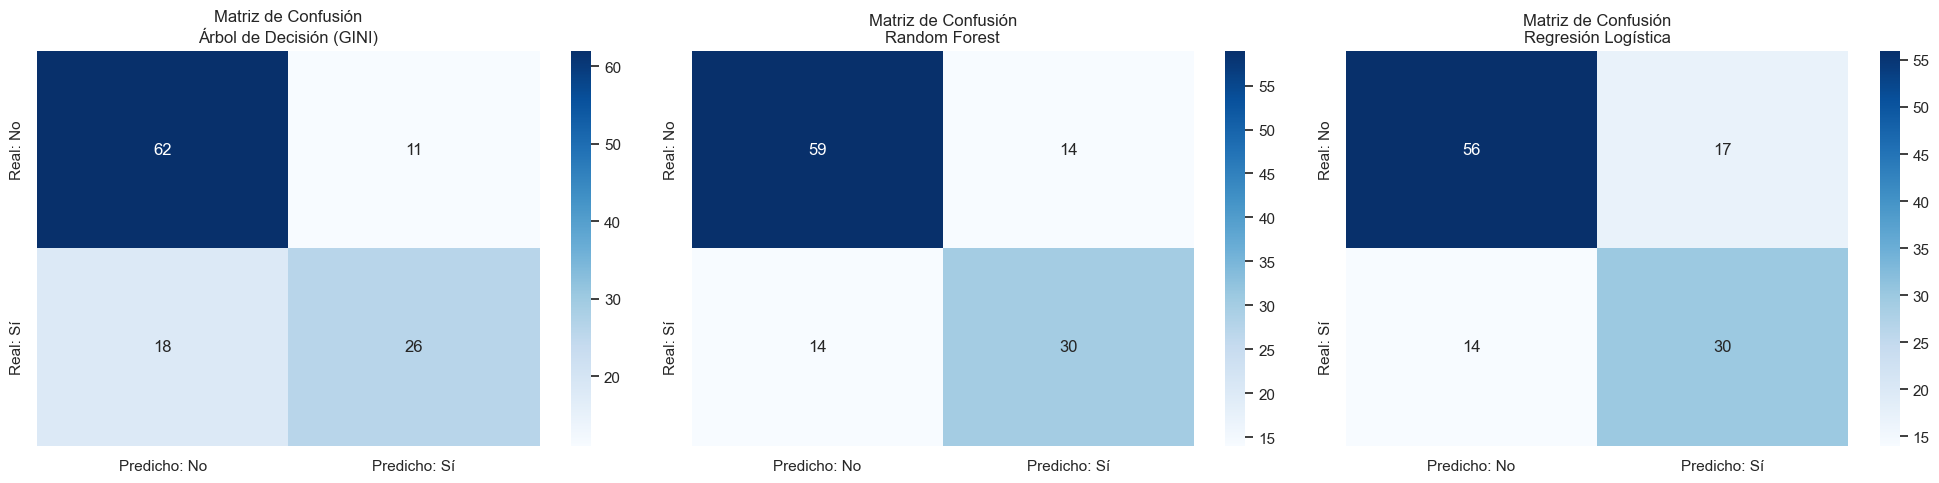

In [62]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

models_preds = [
    ('Árbol de Decisión (GINI)', y_pred_dt),
    ('Random Forest', y_pred_rf),
    ('Regresión Logística', y_pred_lr)
]

for ax, (name, y_pred) in zip(axs, models_preds):
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        data=cm,
        columns=['Predicho: No', 'Predicho: Sí'],
        index=['Real: No', 'Real: Sí']
    )
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Matriz de Confusión\n{name}')

plt.tight_layout()
plt.show()

### 5.3 Reporte de Clasificación Detallado
Se imprime el reporte completo de los tres modelos, incluyendo precisión, recall y F1 por clase.

In [63]:
for name, y_pred in [('Árbol de Decisión (GINI)', y_pred_dt),
                      ('Random Forest', y_pred_rf),
                      ('Regresión Logística', y_pred_lr)]:
    print(f'=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['No Sobrevivió (0)', 'Sobrevivió (1)']))
    print()

=== Árbol de Decisión (GINI) ===
                   precision    recall  f1-score   support

No Sobrevivió (0)       0.78      0.85      0.81        73
   Sobrevivió (1)       0.70      0.59      0.64        44

         accuracy                           0.75       117
        macro avg       0.74      0.72      0.73       117
     weighted avg       0.75      0.75      0.75       117


=== Random Forest ===
                   precision    recall  f1-score   support

No Sobrevivió (0)       0.81      0.81      0.81        73
   Sobrevivió (1)       0.68      0.68      0.68        44

         accuracy                           0.76       117
        macro avg       0.75      0.75      0.75       117
     weighted avg       0.76      0.76      0.76       117


=== Regresión Logística ===
                   precision    recall  f1-score   support

No Sobrevivió (0)       0.80      0.77      0.78        73
   Sobrevivió (1)       0.64      0.68      0.66        44

         accuracy     

### 5.4 Importancia de Variables
Se analizan las variables más relevantes según el Árbol de Decisión y el Random Forest.

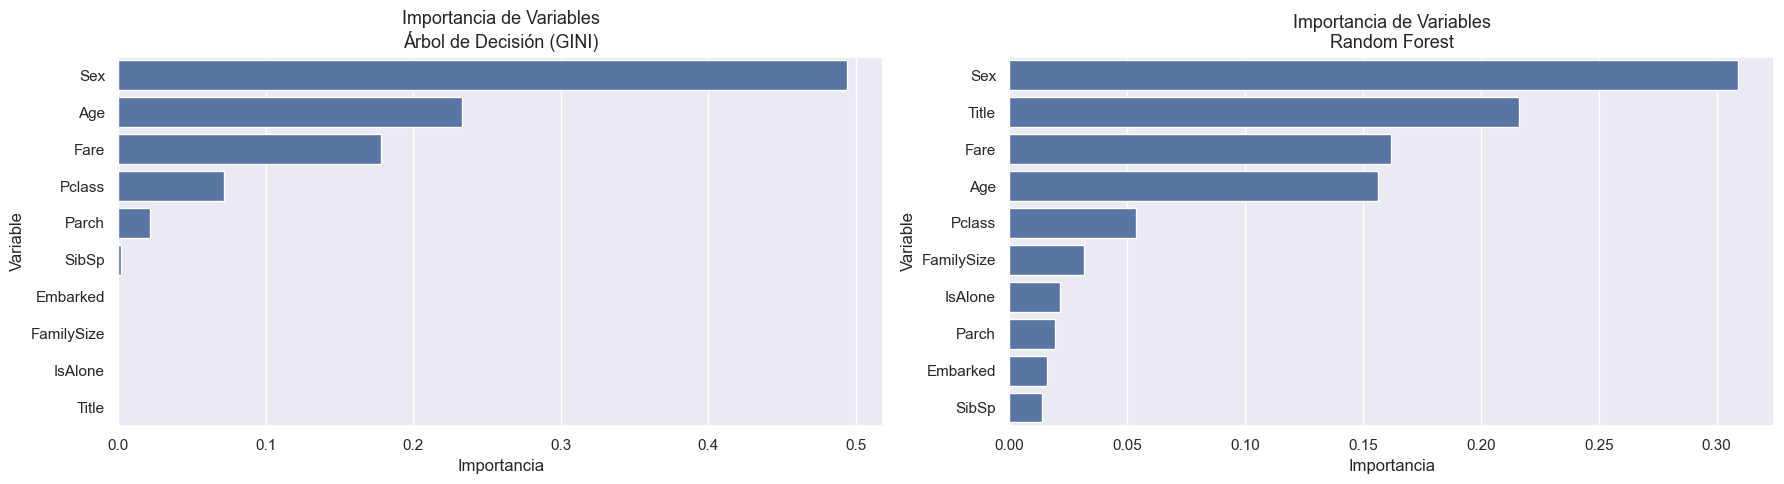

In [64]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

for ax, model, name in zip(axs,
                            [clf_gini, modelRF],
                            ['Árbol de Decisión (GINI)', 'Random Forest']):
    imp_df = pd.DataFrame({
        'Feature Name': X_train.columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    sns.barplot(data=imp_df, x='Importance', y='Feature Name', ax=ax)
    ax.set_title(f'Importancia de Variables\n{name}', fontsize=13)
    ax.set_xlabel('Importancia')
    ax.set_ylabel('Variable')

plt.tight_layout()
plt.show()

### 5.5 Visualización del Árbol de Decisión
Se muestra gráficamente el árbol de decisión entrenado, mostrando las reglas de segmentación utilizadas para clasificar la supervivencia.

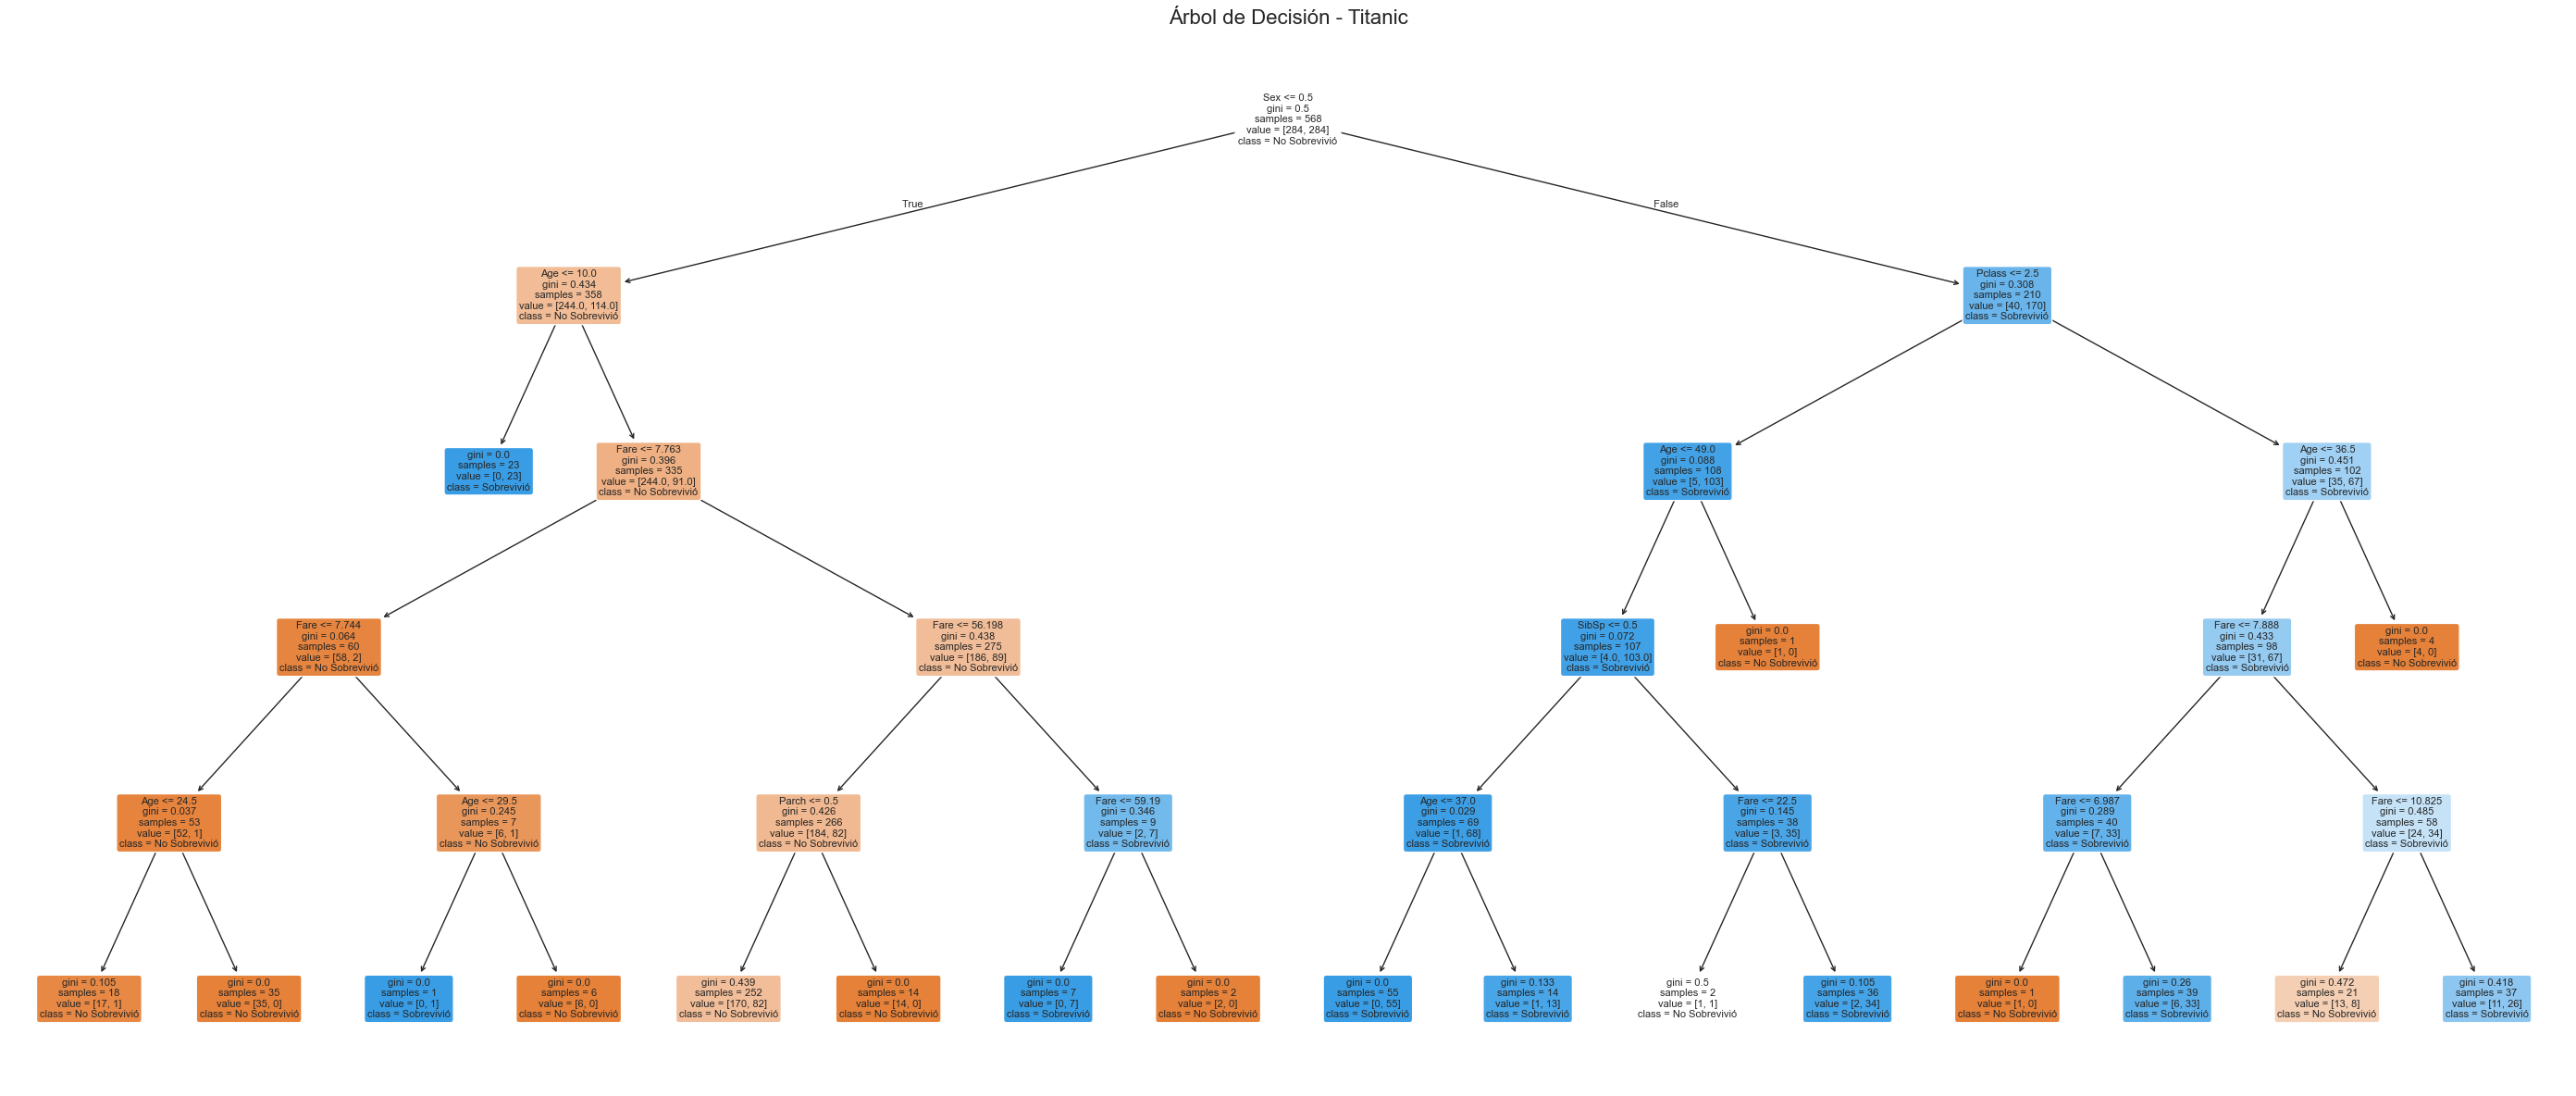

In [65]:
plt.figure(figsize=(28, 12))
tree.plot_tree(
    clf_gini,
    feature_names=X_train.columns,
    class_names=['No Sobrevivió', 'Sobrevivió'],
    rounded=True,
    filled=True,
    fontsize=8
)
plt.title('Árbol de Decisión - Titanic', fontsize=16)
plt.tight_layout()
plt.show()

## 6. Predicción y Exportación

### 6.1 Guardado de Modelos
Se guardan los modelos entrenados en archivos `.pkl` usando `joblib` para reutilizarlos sin necesidad de reentrenar.

In [66]:
joblib.dump(clf_gini, 'modelo_DT_titanic.pkl')
joblib.dump(modelRF,  'modelo_RF_titanic.pkl')
joblib.dump(modelLR,  'modelo_LR_titanic.pkl')
joblib.dump(label_encoder_title, 'label_encoder_title_titanic.pkl')

print('Modelos guardados exitosamente:')
print('  - modelo_DT_titanic.pkl           (Árbol de Decisión)')
print('  - modelo_RF_titanic.pkl           (Random Forest)')
print('  - modelo_LR_titanic.pkl           (Regresión Logística)')
print('  - label_encoder_title_titanic.pkl (LabelEncoder de Title)')

Modelos guardados exitosamente:
  - modelo_DT_titanic.pkl           (Árbol de Decisión)
  - modelo_RF_titanic.pkl           (Random Forest)
  - modelo_LR_titanic.pkl           (Regresión Logística)
  - label_encoder_title_titanic.pkl (LabelEncoder de Title)


### 6.2 Sistema de Predicción para Nuevos Pasajeros
Se implementa un mini sistema en producción que, dado el perfil de un nuevo pasajero, genera predicciones con nivel de confianza.

**Orden de variables requerido:**  
`Pclass, Sex, Age, SibSp, Parch, Fare, Embarked, FamilySize, IsAlone, Title`

In [67]:
# Cargar modelos guardados
modelo_DT = joblib.load('modelo_DT_titanic.pkl')
modelo_RF = joblib.load('modelo_RF_titanic.pkl')
modelo_LR = joblib.load('modelo_LR_titanic.pkl')
le_title  = joblib.load('label_encoder_title_titanic.pkl')

print('Valores de Entrada:')
print('-' * 35)

# --- Perfil del pasajero a predecir ---
pclass    = 3        # Clase del boleto (1, 2 o 3)
sex       = 'male'   # Género: 'male' o 'female'
age       = 28.0     # Edad en años
sibsp     = 0        # Hermanos/cónyuge a bordo
parch     = 0        # Padres/hijos a bordo
fare      = 8.05     # Tarifa del boleto
embarked  = 'S'      # Puerto: 'S'=Southampton, 'C'=Cherbourg, 'Q'=Queenstown
title_str = 'Mr'     # Título: Mr, Mrs, Miss, Master, Rare

# Transformaciones (mismo proceso que el entrenamiento)
sex_num      = 0 if sex == 'male' else 1
embarked_num = {'S': 0, 'C': 1, 'Q': 2}[embarked]
family_size  = sibsp + parch + 1
is_alone     = 1 if family_size == 1 else 0
title_num    = le_title.transform([title_str])[0]

nuevo_pasajero = pd.DataFrame([{
    'Pclass':     pclass,
    'Sex':        sex_num,
    'Age':        age,
    'SibSp':      sibsp,
    'Parch':      parch,
    'Fare':       fare,
    'Embarked':   embarked_num,
    'FamilySize': family_size,
    'IsAlone':    is_alone,
    'Title':      title_num
}])

print('\nDatos del nuevo Pasajero:')
print('-' * 35)
print(nuevo_pasajero.to_string(index=False))

print('\nPredicción de los modelos:')
print('-' * 35)
for nombre, modelo in [('Árbol de Decisión ', modelo_DT),
                        ('Random Forest     ', modelo_RF),
                        ('Reg. Logística    ', modelo_LR)]:
    pred  = modelo.predict(nuevo_pasajero)[0]
    prob  = modelo.predict_proba(nuevo_pasajero)[0]
    label = 'Sobrevivió' if pred == 1 else 'No sobrevivió'
    print(f'{nombre}: {label}  (confianza: {max(prob)*100:.1f}%)')

Valores de Entrada:
-----------------------------------

Datos del nuevo Pasajero:
-----------------------------------
 Pclass  Sex  Age  SibSp  Parch  Fare  Embarked  FamilySize  IsAlone  Title
      3    0 28.0      0      0  8.05         0           1        1      2

Predicción de los modelos:
-----------------------------------
Árbol de Decisión : No sobrevivió  (confianza: 67.5%)
Random Forest     : No sobrevivió  (confianza: 72.0%)
Reg. Logística    : No sobrevivió  (confianza: 77.0%)


---
## Conclusiones

- **Exploración:** El dataset presenta desbalance de clases (~62% No sobrevivió / ~38% Sobrevivió). Las variables más correlacionadas con la supervivencia son `Sex`, `Pclass`, `Fare` y `Title`.

- **Preprocesamiento:** Se manejaron correctamente los valores nulos: `Age` por mediana agrupada por `Title`, `Embarked` por moda, y `Cabin` fue eliminada por alto porcentaje de nulos (77%). Se crearon features relevantes: `FamilySize`, `IsAlone` y `Title`.

- **Modelos:** Se entrenaron tres modelos de clasificación con clases balanceadas via oversampling. El **Random Forest** tiende a obtener el mejor balance entre precisión en entrenamiento y generalización en prueba.

- **Variables más importantes:** `Sex` (género), `Title` (título social) y `Fare` (tarifa) resultaron ser las variables con mayor poder predictivo, consistente con la realidad histórica: mujeres y niños primero, y prioridad para pasajeros de primera clase.

- **Predicción:** El sistema implementado permite ingresar el perfil de cualquier pasajero y obtener la predicción de supervivencia con nivel de confianza de los tres modelos.